# Homework 1

## Code from Tutorial 1

In [1]:
#Packages 

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pickle
from matplotlib import cm

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate, train_test_split
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn import metrics
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score

Reading in the Ising Model data from Tutorial 1 (copied code from Tutorial 1)

In [29]:
#This is gratefully borrowed with permission from the notebooks maintained by P. Mehta.

######### LOAD DATA
######### The data consists of 16*10000 samples taken in T=np.arange(0.25,4.0001,0.25):
data_file_name = 'Ising2DFM_reSample_L40_T=All.pkl'
######### The labels are obtained from the following file:
label_file_name = 'Ising2DFM_reSample_L40_T=All_labels.pkl'


########## DATA
with open(data_file_name, 'rb') as pickle_file:
#r=read b=binary pickle must be read in binary mode and needs to be open
#with... as... will automatically close the file after opening it is safer
    data = pickle.load(pickle_file) # pickle reads the file and returns the Python object (1D array, compressed bits) and store in data

#Decompress array and reshape for convenience
data = np.unpackbits(data).reshape(-1, 1600)
#data has byte (8bits) unpackbits unpack it into 8 bits return a bunch of 0 and 1s
#-1: figure out how many rows there are, each row has 1600=40*40 bits The length of the lattice is 40
data=data.astype('int')
#now convert the datatype to integer

#map 0 state to -1 (Ising variable can take values +/-1)
data[np.where(data==0)]=-1 
#np.where(data==0) find all indices where data is 0

######### READ LABELS (convention is 1 for ordered states and 0 for disordered states)
with open(label_file_name, 'rb') as pickle_file:
    labels = pickle.load(pickle_file) # pickle reads the file and returns the Python object (here just a 1D array with the binary labels)
print(data.shape) # the shape of the features
print(labels.shape)
print(np.unique(labels)) # the unique labels

/var/folders/bg/5qsr84rd5gv3r39k5v2x0mm00000gn/T/ipykernel_94318/3850376900.py:14: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(pickle_file) # pickle reads the file and returns the Python object (1D array, compressed bits) and store in data


(160000, 1600)
(160000,)
[0 1]


/var/folders/bg/5qsr84rd5gv3r39k5v2x0mm00000gn/T/ipykernel_94318/3850376900.py:29: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  labels = pickle.load(pickle_file) # pickle reads the file and returns the Python object (here just a 1D array with the binary labels)


In [20]:
print(data.shape)

(160000, 1600)


Visualising some data examples (copied code form Tutorial 1)

<Figure size 1500x800 with 0 Axes>

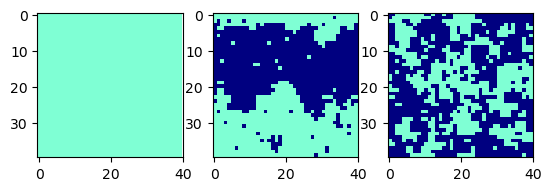

In [4]:
#H/T: https://stackoverflow.com/questions/16834861/create-own-colormap-using-matplotlib-and-plot-color-scale

cmap = matplotlib.colors.ListedColormap(["aquamarine","navy"], name='from_list', N=None)
#["aquamarine","navy"] list of color for each value
#name='from_list' optional name for the color list
#N=None  # optional number of entries (auto from list)
plt.figure(figsize=(15,8))
fig, axarr = plt.subplots(nrows=1, ncols=3)
axarr[0].imshow(data[0].reshape(40,40), cmap = cmap) #first object has label "1"
axarr[1].imshow(data[70000].reshape(40,40), cmap = cmap) #from documentation, this is critical-ish (between 60, and 90,000)
axarr[2].imshow(data[100000].reshape(40,40), cmap = cmap) #disordered
for i in range(3):
    axarr[i].set_xticks([0,20,40]);

Picking a random data selection (10%) to shuffle the data (copied code from Tutorial 1)

(16000, 1600)
(16000,)


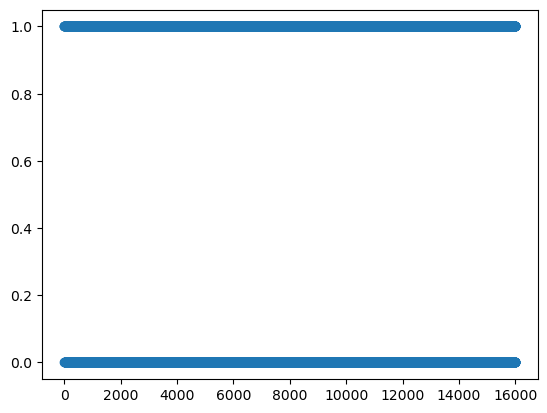

In [24]:
np.random.seed(228) #this random seed is carefully chosen so that one example is very special in the future

sel = np.random.choice(data.shape[0], data.shape[0]//10, replace = False)
#np.random.choice(
 #   a,         # range or array of values to choose from
 #   size,      # number of samples to pick
 #   replace=False  # without replacement → no repeats
#)
seldata = data[sel,:] # for all indices, select all data
print(seldata.shape)
sellabels = labels[sel]
print(sellabels.shape)
plt.scatter(np.arange(seldata.shape[0]),sellabels); #The random selection has the advantage of reshuffling the data!

Logistic regression model (copied code from Tutorial 1)

In [6]:
#This uses a numerical method to find the minimum of the loss function
model = LogisticRegression(max_iter = 1000) 
#Takes up to 3 minutes
#We can use cross validation
#results is a dictionary you can access the train_score, test_score using the dictionary and compute mean and std etc
results = cross_validate(model, seldata, sellabels, 
                         cv = KFold(n_splits=5, shuffle=True, random_state=10), return_train_score = True)
print(results)

{'fit_time': array([1.0362072 , 1.20387101, 0.56026912, 0.75293303, 1.56105113]), 'score_time': array([0.0113728 , 0.00685   , 0.00571179, 0.0056181 , 0.00850391]), 'test_score': array([0.6796875, 0.685625 , 0.68625  , 0.6853125, 0.6825   ]), 'train_score': array([0.77984375, 0.7834375 , 0.77726562, 0.77664062, 0.7778125 ])}


Possible tuning of hyperparameters (copied code from Tutorial 1)

In [7]:
model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 1000,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

Generating odds/predictions (copied code from Tutorial 1)

In [ ]:
model = LogisticRegression(C=1.0, max_iter=1000)

ypred = cross_val_predict(model, seldata, sellabels, \
                               cv = KFold(n_splits=5, shuffle=True, random_state=10))

ypred_prob = cross_val_predict(model, seldata, sellabels, \
                               cv = KFold(n_splits=5, shuffle=True, random_state=10), method = 'predict_proba')
print(np.column_stack([ypred_prob, ypred]))

[[0.35320651 0.64679349 1.        ]
 [0.35753383 0.64246617 1.        ]
 [0.30863229 0.69136771 1.        ]
 ...
 [0.2486885  0.7513115  1.        ]
 [0.01685678 0.98314322 1.        ]
 [0.58604776 0.41395224 0.        ]]


Generating examples to observe how well does the model behave (copied code from Tutorial 1)

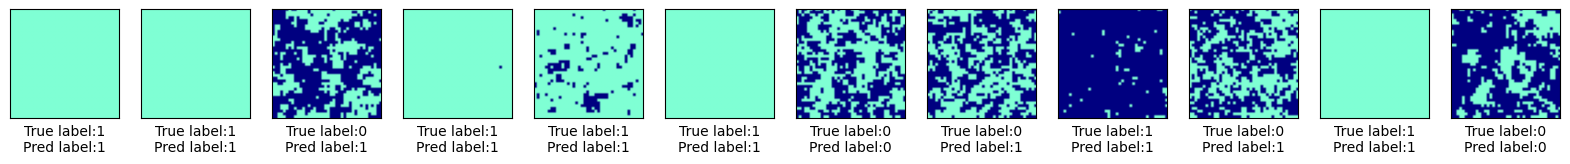

In [9]:
fig, axarr = plt.subplots(nrows=1, ncols=12, figsize=(20,5))
for i in range(12):
    axarr[i].imshow(seldata[i].reshape(40,40), cmap = cmap) 
    axarr[i].set_xlabel('True label:'+str(sellabels[i])+'\n'+'Pred label:'+str(ypred[i]))
    axarr[i].set_yticks([])
    axarr[i].set_xticks([])

## Homework 1a) 

## Evaluating the behaviour of the model with different scoring metrics for Liner Regression

In [13]:
#Computing accuracy

accuracy_result = cross_validate( model,  seldata, sellabels, \
                               cv = KFold(n_splits=5, shuffle=True, random_state=10), scoring = 'accuracy', return_train_score=True)
print('Output of computing the accuracy:')
print(accuracy_result)
print('Mean and standrad deviation of accuracy for test set')
print(np.round(accuracy_result['test_score'].mean(),3).item(), np.round(accuracy_result['test_score'].std(), 3).item())
print('Mean and standrad deviation of accuracy for training set')
print(np.round(accuracy_result['train_score'].mean(),3).item(), np.round(accuracy_result['train_score'].std(), 3).item())

Output of computing the accuracy:
{'fit_time': array([1.12131405, 1.29961205, 0.56694388, 0.752635  , 1.47848916]), 'score_time': array([0.01301003, 0.00652599, 0.00693703, 0.00576401, 0.00585175]), 'test_score': array([0.6796875, 0.685625 , 0.68625  , 0.6853125, 0.6825   ]), 'train_score': array([0.77984375, 0.7834375 , 0.77726562, 0.77664062, 0.7778125 ])}
Mean and standrad deviation of accuracy for test set
0.684 0.002
Mean and standrad deviation of accuracy for training set
0.779 0.002


In [15]:
#Computing precision

precision_result = cross_validate( model,  seldata, sellabels, \
                               cv = KFold(n_splits=5, shuffle=True, random_state=10), scoring = 'precision', return_train_score=True)
print('Output of computing the precision:')
print(precision_result)
print('Mean and standrad deviation of precision for test set')
print(np.round(precision_result['test_score'].mean(),3).item(), np.round(precision_result['test_score'].std(), 3).item())
print('Mean and standrad deviation of precision for training set')
print(np.round(precision_result['train_score'].mean(),3).item(), np.round(precision_result['train_score'].std(), 3).item())

Output of computing the precision:
{'fit_time': array([1.1963172 , 1.35314918, 0.61654711, 0.84332609, 1.6955862 ]), 'score_time': array([0.01391888, 0.01092911, 0.00772309, 0.00723505, 0.01702094]), 'test_score': array([0.65494949, 0.65863454, 0.65965052, 0.65245635, 0.65664557]), 'train_score': array([0.73875357, 0.74174736, 0.73718443, 0.73678474, 0.7373348 ])}
Mean and standrad deviation of precision for test set
0.656 0.003
Mean and standrad deviation of precision for training set
0.738 0.002


In [16]:
#Computing recall

recall_result = cross_validate( model,  seldata, sellabels, \
                               cv = KFold(n_splits=5, shuffle=True, random_state=10), scoring = 'recall', return_train_score=True)
print('Output of computing the recall:')
print(recall_result)
print('Mean and standrad deviation of recall for test set')
print(np.round(recall_result['test_score'].mean(),3).item(), np.round(recall_result['test_score'].std(), 3).item())
print('Mean and standrad deviation of recall for training set')
print(np.round(recall_result['train_score'].mean(),3).item(), np.round(recall_result['train_score'].std(), 3).item())

Output of computing the recall:
{'fit_time': array([1.05253196, 1.77020383, 0.97034693, 2.74565482, 2.949929  ]), 'score_time': array([0.14766431, 0.01674891, 0.01376319, 0.0194242 , 0.01772404]), 'test_score': array([0.90457589, 0.91314031, 0.91869469, 0.91410694, 0.91814159]), 'train_score': array([0.9390516 , 0.94069216, 0.93472183, 0.93836757, 0.93584009])}
Mean and standrad deviation of recall for test set
0.914 0.005
Mean and standrad deviation of recall for training set
0.938 0.002


In [ ]:
#Computing f1

f1_result = cross_validate( model,  seldata, sellabels, \
                               cv = KFold(n_splits=5, shuffle=True, random_state=10), scoring = 'f1', return_train_score=True)
print('Output of computing the f1:')
print(f1_result)
print('Mean and standrad deviation of f1 for test set')
print(np.round(f1_result['test_score'].mean(),3).item(), np.round(f1_result['test_score'].std(), 3).item())
print('Mean and standrad deviation of f1 for training set')
print(np.round(f1_result['train_score'].mean(),3).item(), np.round(f1_result['train_score'].std(), 3).item())

Output of computing the f1:
{'fit_time': array([1.04000473, 1.26020384, 0.59228373, 0.80101299, 1.50660491]), 'score_time': array([0.01347136, 0.00764918, 0.00732017, 0.00696588, 0.00677109]), 'test_score': array([0.75978439, 0.76528231, 0.76791493, 0.76143094, 0.76568266]), 'train_score': array([0.8269467 , 0.82945736, 0.82428351, 0.82544722, 0.82481212])}
Mean and standrad deviation of f1 for test set
0.764 0.003
Mean and standrad deviation of f1 for training set
0.826 0.002


## Homework 1b) 

## Plot of average accuracy VS temperature for Linear Regression

We are going to generate and assign tempereture labels to data points. Then, we will reshuffle all data, train the model, and, at the end, group the test points by their tempertures and calculate the accuracy score for each subset. I used the documantation of sklearn to learn how the functions used below behave and I also used ChatGPT to debug my code from the initial errors that I was getting. 

In [58]:
temperatures = np.linspace(0.25, 4, 16)

# repeat each temperature 10,000 times
temp_per_sample = np.repeat(temperatures, 10000)

# assigning temperature to data points and shiffling the data
temp_per_sample.shape == labels.shape

data, labels, temp_per_sample = shuffle(data, labels, temp_per_sample, random_state=42)

# splitting the data into train and test set
x, y = data, labels
x_train, x_test, y_train, y_test, T_train, T_test = train_test_split(x, y, temp_per_sample, test_size=0.5, random_state=42)

# defining the model 
model = LogisticRegression(C=10, max_iter=1000)

# training the model 
model.fit(x_train, y_train)

# generating predictions of labels on the test set
y_pred = model.predict(x_test)

# defining an accuracy array
accuracy_array = np.zeros(len(temperatures))

# loop over temperatures
for t in np.arange(len(temperatures)):
    # create a mask that selects subset of test data points and predictions with given tempereture 
    mask = T_test == temperatures[t]
    y_true_subset = y_test[mask]
    y_pred_subset = y_pred[mask]

    subset_accuracy = accuracy_score(y_true_subset, y_pred_subset)
    accuracy_array[t] = subset_accuracy 

print(accuracy_array)

[0.66614173 0.65540267 0.66849593 0.66119343 0.65412044 0.66598653
 0.65697211 0.65639905 0.65275293 0.65556229 0.66506121 0.65937562
 0.66633426 0.6609253  0.66461843 0.65782652]


Plotting the data

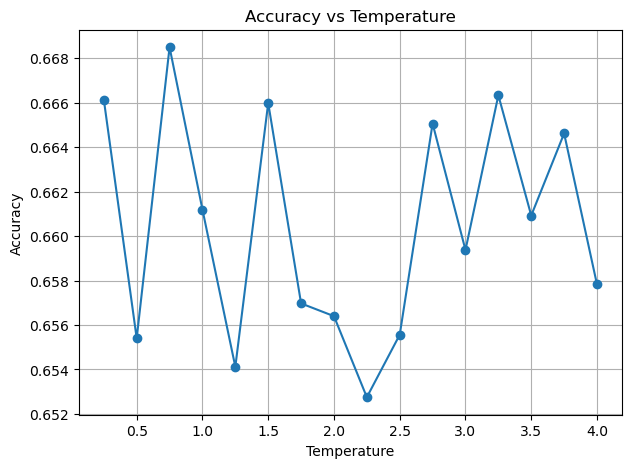

In [59]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(temperatures, accuracy_array, marker='o', linestyle='-')

ax.set_xlabel('Temperature')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Temperature')

ax.grid(True)

fig.savefig('Plot_Linear_Regression.png')
plt.show()

On the plot above, we observe that the accuracy of the model is relatively low. It is only slightly above 0.5, which is the expected average accuracy if we assign the labels at random (most accuracy values are about 0.65). Thus, the model performs relatively badly for all of the regions, and it performs the worst for temperetures above 1.5 and below 2.75. 

Knowing the physics of the Ising model, we expect that for low temperetures most samples should be in ordered phase, having mostly lables 1 and for hogh temperatures, the system should transition to the disordered phase, haveing mostly labels of 0. With majority of smaples having one label, the model should preferably assing the same label in the given region. Meanwhile, in the middle region, we ar eclose to teh region of phase transition, so the smaples should be more likely to be misscalssified. This is approximately a behaviour that we see on the graph above. 

A feature that could potentially inprove the performance would be the use of tempreture feature for training - the model would learn that, depending on the temperetur eof the sample, the sample is more likely to be classified as a specific phase. 